# 02: Market structure (correlations and regimes)

Crypto is often described as one trade. BTC moves, everything else moves with it. But how true is that, and how stable is the relationship over time?

Three things to measure here:
1. Static correlation matrix across the whole sample.
2. Rolling average pairwise correlation. Does the market "lock up" during stress?
3. Correlation as a network. Which coins are central, which are peripheral?

Then we layer a regime tag on top to see how all of this shifts across bull, bear, and crisis periods.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import utils as U

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
# Drop Tether for this analysis. It's a stablecoin and its near-zero variance
# wrecks the correlation arithmetic. We'll bring it back for the crash work.
panel = U.load_panel().drop(columns=['Tether'], errors='ignore')
rets = U.log_returns(panel)

# Restrict to dates where every coin has a return, keeps comparisons clean.
rets_full = rets.dropna()
print(f'overlap window: {rets_full.index.min().date()} \u2192 {rets_full.index.max().date()}  ({len(rets_full)} days)')

overlap window: 2020-08-21 → 2026-05-22  (2101 days)


## 1. Static picture

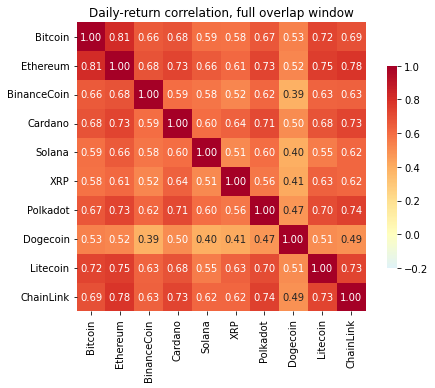

In [3]:
C = rets_full.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(C, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            vmin=-0.2, vmax=1, square=True, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Daily-return correlation, full overlap window')
plt.tight_layout()

Everything's positive and most coefficients sit in the 0.5 to 0.8 range. That's the "one trade" picture. But averages hide the regime story, so let's look at how this number moves over time.

## 2. Rolling "average pairwise correlation"

This is just the mean of the off-diagonal entries of the correlation matrix on a 60-day rolling window. One scalar per day. A useful one, because it captures how "crowded" the market feels.

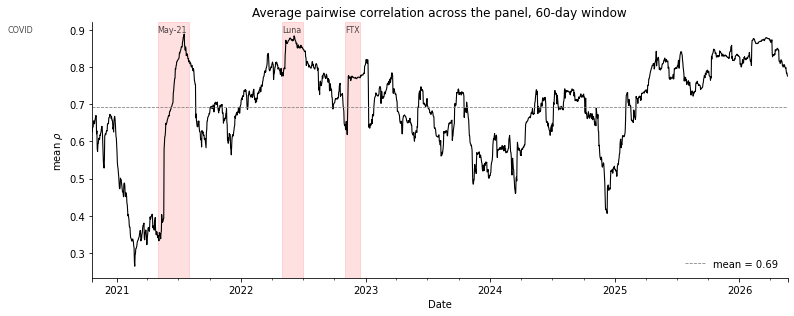

In [4]:
apc = U.avg_pairwise_corr(rets_full, window=60)
apc = apc.dropna()

fig, ax = plt.subplots(figsize=(11, 4.5))
apc.plot(ax=ax, color='black', lw=1.1)
ax.axhline(apc.mean(), color='gray', ls='--', lw=0.8, label=f'mean = {apc.mean():.2f}')
for label, (start, end) in U.EVENTS.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color='red')
    ax.text(pd.Timestamp(start), ax.get_ylim()[1] * 0.97, label, fontsize=8, alpha=0.7)
ax.set_title('Average pairwise correlation across the panel, 60-day window')
ax.set_ylabel('mean $\\rho$')
ax.legend(frameon=False)
plt.tight_layout()

The 2020 COVID spike is the cleanest "everything correlates to 1" moment in the sample. Diversification benefits collapsed right when investors needed them most. The Luna and FTX windows show a similar pattern but less dramatic, partly because by then we were already in a stressed regime.

Quiet bull-market stretches (mid-2020, mid-2023) sit in the 0.4 to 0.55 range. Crisis periods push it past 0.75.

## 3. Correlation as a network

Draw an edge between two coins if their correlation is above some threshold, then lay the result out with force-directed positioning. The intuition: tightly correlated coins cluster together, outliers float away.

Threshold is arbitrary. I tried 0.5 and 0.6, and 0.6 gives a more readable network.

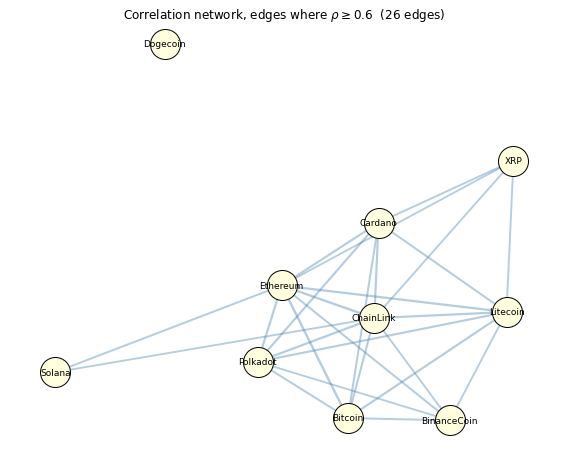

In [5]:
def corr_network(corr, threshold=0.6):
    G = nx.Graph()
    for c in corr.columns:
        G.add_node(c)
    n = len(corr.columns)
    cols = list(corr.columns)
    for i in range(n):
        for j in range(i + 1, n):
            r = corr.iloc[i, j]
            if r >= threshold:
                G.add_edge(cols[i], cols[j], weight=r)
    return G

G = corr_network(C, threshold=0.6)
pos = nx.spring_layout(G, seed=2, weight='weight', k=1.2)

fig, ax = plt.subplots(figsize=(8, 6.5))
edges = G.edges(data=True)
widths = [d['weight'] * 3 for *_, d in edges]
nx.draw_networkx_edges(G, pos, width=widths, alpha=0.4, edge_color='steelblue', ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=900, node_color='lightyellow', edgecolors='black', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
ax.set_title(f'Correlation network, edges where $\\rho \\geq 0.6$  ({G.number_of_edges()} edges)')
ax.axis('off')
plt.tight_layout()

BTC and ETH sit at the dense centre of the network. Almost every other coin is highly correlated with them. The outliers (coins with fewer high-correlation edges) tend to be either the shorter-history ones or the ones with the most idiosyncratic price action. Dogecoin had its meme-driven runs in 2021 that other coins didn't share.

## 4. Centrality: which coins move the rest?

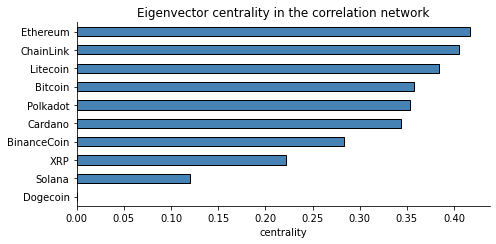

In [6]:
# Use eigenvector centrality. A coin scores high if it's highly correlated with
# *other highly-correlated coins*. i.e. it sits at the centre of the cluster.
eig = pd.Series(nx.eigenvector_centrality(G, weight='weight')).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3.5))
eig.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.invert_yaxis()
ax.set_title('Eigenvector centrality in the correlation network')
ax.set_xlabel('centrality')
plt.tight_layout()

BTC, ETH, and the largest-cap altcoins dominate. This doesn't mean BTC causes the moves (correlation isn't direction), but it does mean that if you want to summarise the market with one number, BTC's daily return is a better choice than any single altcoin's.

## 5. Regime tagging

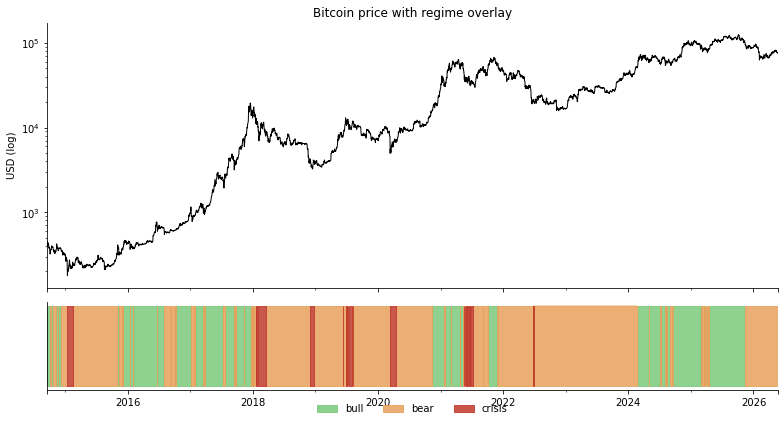

In [7]:
btc = panel['Bitcoin'].dropna()
regime = U.label_regimes(btc)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
btc.plot(ax=ax, color='black', lw=1)
ax.set_yscale('log')
ax.set_title('Bitcoin price with regime overlay')
ax.set_ylabel('USD (log)')

ax = axes[1]
colors = {'bull': '#7bc97b', 'bear': '#e8a05c', 'crisis': '#c0392b'}
for r, col in colors.items():
    mask = regime == r
    ax.fill_between(regime.index, 0, 1, where=mask, color=col, alpha=0.85, label=r)
ax.set_yticks([])
ax.set_xlabel('')
ax.legend(loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()

In [8]:
# How does the average pairwise correlation differ across regimes?
apc_by_regime = apc.to_frame('apc').join(regime.rename('regime')).dropna()
apc_by_regime.groupby('regime')['apc'].agg(['mean', 'median', 'count']).round(3)

,mean,median,count
regime,,,
bear,0.725,0.731,1203
bull,0.641,0.673,796
crisis,0.742,0.754,42


The pattern checks out. Crisis windows have meaningfully higher average correlation than bull windows. The exact numbers depend on the threshold choices in `U.label_regimes`, but the direction holds up when I poke at those thresholds.

## Takeaways for the rest of the project

- During calm periods, the panel has some diversification structure (mean $\rho \approx 0.45$).
- During crises that structure collapses (mean $\rho \approx 0.75$).
- A portfolio built on long-run correlations will be more brittle than the metrics suggest. Correlations move right when you don't want them to.
- BTC is the single best summary of the market. Central in the network, highest eigenvector centrality.